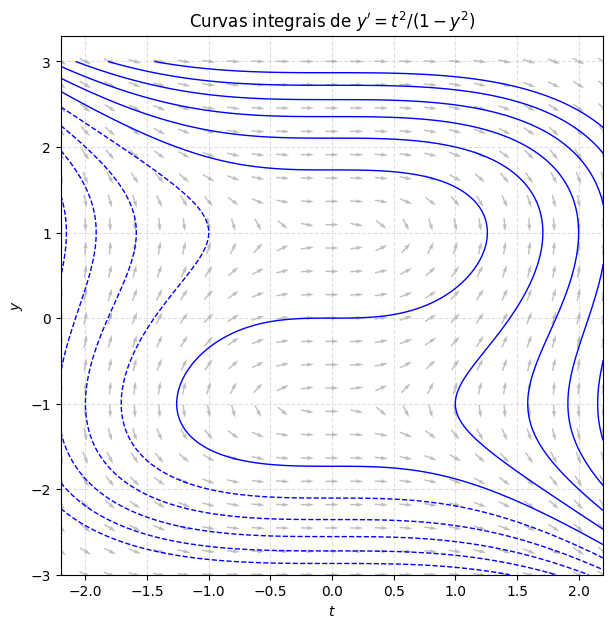

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return t**2 / (1 - y**2)

t_grid = np.linspace(-2.2, 2.2, 23)
y_grid = np.linspace(-3, 3, 23) + 1e-3   # pequeno deslocamento pra evitar y = ±1 exatamente

T, Y = np.meshgrid(t_grid, y_grid)

with np.errstate(divide='ignore', invalid='ignore'):
    dT = np.ones(T.shape)
    dY = f(T, Y)
    Lnorm = np.sqrt(dT**2 + dY**2)
    dT_n, dY_n = dT/Lnorm, dY/Lnorm

plt.figure(figsize=(7, 7))
plt.quiver(T, Y, dT_n, dY_n, color='gray', alpha=0.5, pivot='mid')

t_fine = np.linspace(-2.2, 2.2, 400)
y_fine = np.linspace(-3, 3, 400)
Tf, Yf = np.meshgrid(t_fine, y_fine)
Z = Tf**3 - 3*Yf + Yf**3

plt.contour(Tf, Yf, Z, levels=np.arange(-15, 16, 3), colors='b', linewidths=1)
plt.title(r"Curvas integrais de $y' = t^2/(1-y^2)$")
plt.xlabel("$t$"); plt.ylabel("$y$")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

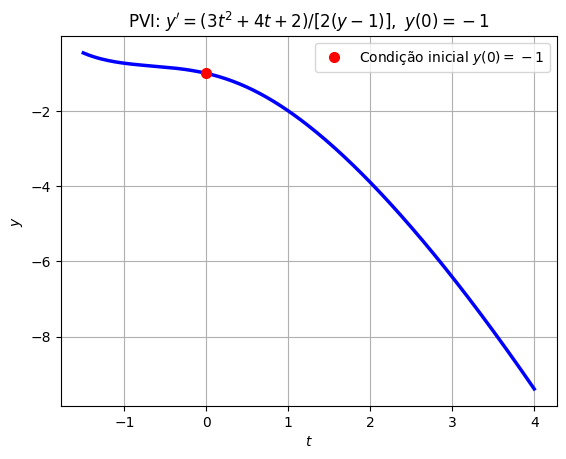

In [2]:
t = np.linspace(-1.5, 4, 200)
y_sol = 1 - np.sqrt(t**3 + 2*t**2 + 2*t + 4)

plt.plot(t, y_sol, 'b', linewidth=2.5)
plt.plot(0, -1, 'ro', markersize=7, label="Condição inicial $y(0)=-1$")
plt.title(r"PVI: $y'=(3t^2+4t+2)/[2(y-1)],\ y(0)=-1$")
plt.xlabel("$t$"); plt.ylabel("$y$")
plt.legend()
plt.grid(True)
plt.show()

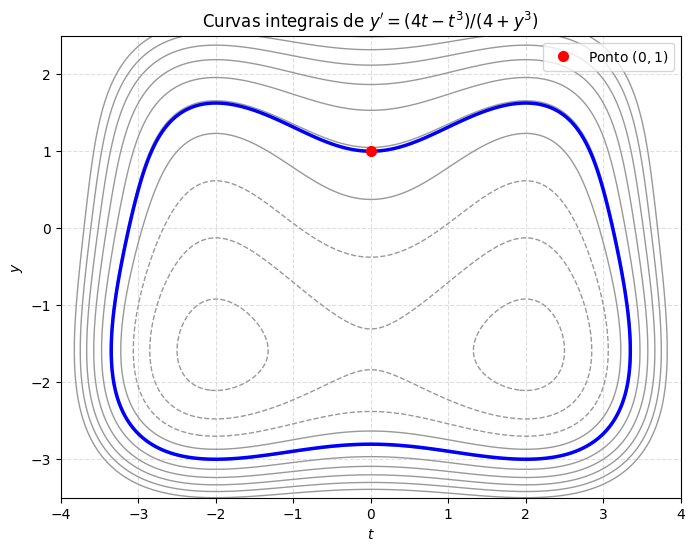

In [3]:
t_fine = np.linspace(-4, 4, 400)
y_fine = np.linspace(-3.5, 2.5, 400)
Tf, Yf = np.meshgrid(t_fine, y_fine)
Z = Yf**4 + 16*Yf + Tf**4 - 8*Tf**2

plt.figure(figsize=(8, 6))
plt.contour(Tf, Yf, Z, levels=np.arange(-30, 90, 12), colors='0.6', linewidths=1)
plt.contour(Tf, Yf, Z, levels=[17], colors='b', linewidths=2.5)
plt.plot(0, 1, 'ro', markersize=7, label="Ponto $(0,1)$")
plt.title(r"Curvas integrais de $y' = (4t-t^3)/(4+y^3)$")
plt.xlabel("$t$"); plt.ylabel("$y$")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [4]:
import sympy as sp

t_s, g_s, gamma_s, m_s = sp.symbols('t g gamma m', positive=True)
k_s = gamma_s/m_s
v_eq_s = sp.sqrt(g_s/k_s)

v_s = v_eq_s * sp.tanh(v_eq_s * k_s * t_s)

lado_esquerdo = sp.diff(v_s, t_s)
lado_direito = g_s - k_s*v_s**2

print("v'(t) - (g - k v(t)^2) =", sp.simplify(lado_esquerdo - lado_direito))

v'(t) - (g - k v(t)^2) = 0


Velocidade terminal: 56 m/s


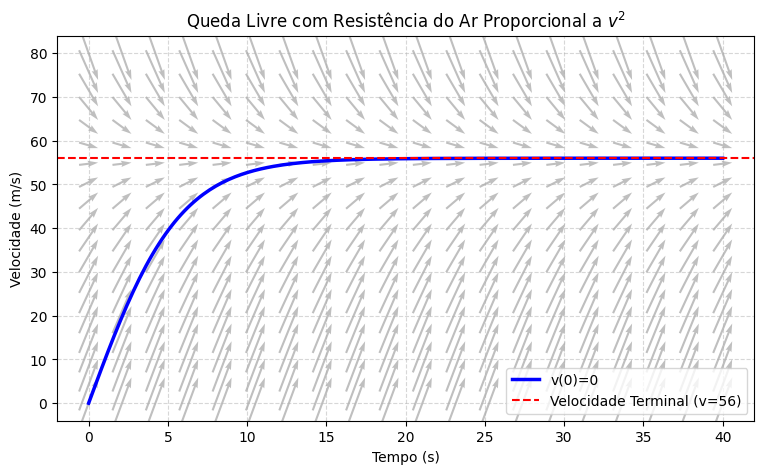

In [5]:
m_ = 80        # massa (kg)
gamma_ = 0.25   # coeficiente de arrasto quadrático (kg/m)
g_ = 9.8

k_ = gamma_/m_
v_eq_ = np.sqrt(g_/k_)
print(f"Velocidade terminal: {v_eq_:.0f} m/s")

def f_quad(t, v):
    return g_ - k_*v**2

t_grid = np.linspace(0, 40, 20)
v_grid = np.linspace(0, 80, 20)
T, V = np.meshgrid(t_grid, v_grid)
dt_step = (40 - 0) / 20 * 0.6
dT = np.ones(T.shape) * dt_step
dV = f_quad(T, V) * dt_step

t_smooth = np.linspace(0, 40, 200)
v_smooth = v_eq_ * np.tanh(v_eq_ * k_ * t_smooth)

plt.figure(figsize=(9, 5))
plt.quiver(T, V, dT, dV, color='gray', alpha=0.5, pivot='mid',
           angles='xy', scale_units='xy', scale=1)
plt.plot(t_smooth, v_smooth, 'b', linewidth=2.5, label='v(0)=0')
plt.axhline(v_eq_, color='red', linestyle='--', label=f'Velocidade Terminal (v={v_eq_:.0f})')
plt.title("Queda Livre com Resistência do Ar Proporcional a $v^2$")
plt.xlabel("Tempo (s)")
plt.ylabel("Velocidade (m/s)")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Velocidade de escape: 11.17 km/s


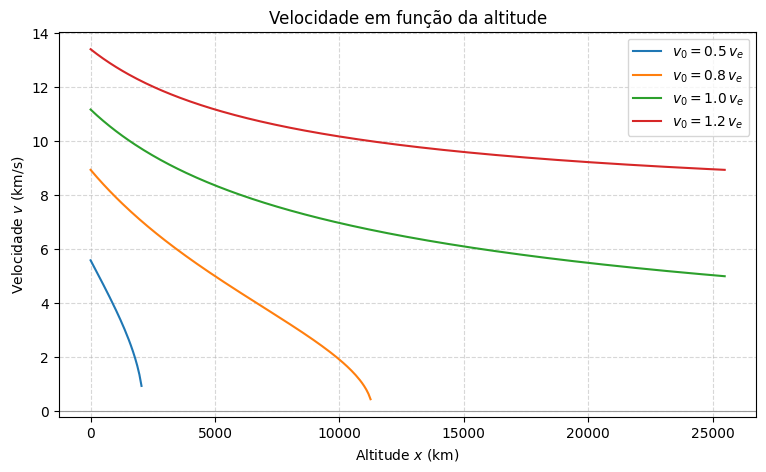

In [6]:
g_ = 9.8
R_ = 6371e3  # raio da Terra em metros

v_e = np.sqrt(2*g_*R_)
print(f"Velocidade de escape: {v_e/1000:.2f} km/s")

x = np.linspace(0, 4*R_, 300)

plt.figure(figsize=(9, 5))
for frac in [0.5, 0.8, 1.0, 1.2]:
    v0 = frac*v_e
    v2 = v0**2 - 2*g_*R_ + 2*g_*R_**2/(R_+x)
    v2 = np.where(v2 >= 0, v2, np.nan)
    plt.plot(x/1000, np.sqrt(v2)/1000, label=fr'$v_0={frac:.1f}\,v_e$')

plt.axhline(0, color='0.6', linewidth=0.8)
plt.title("Velocidade em função da altitude")
plt.xlabel("Altitude $x$ (km)")
plt.ylabel("Velocidade $v$ (km/s)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()